# Step 4 — Specification

> Full prompt for this step, reproduced verbatim (CLAUDE.md code-style rule:
> each notebook opens with its own spec so it is self-contained).

STEP 4 — Covariance: EWMA variant

Read CLAUDE.md first. Implement ONLY this step, in notebooks/04_ewma.ipynb.
First cell: this entire prompt in markdown, titled "# Step 4 — Specification".

## Goal
Produce a third covariance estimate — EWMA (exponentially weighted) — for
the same 6 optimizable assets and same month-end schedule as step 3.
EWMA attacks the step-3 diagnosis: the rolling window's "step artifact"
(e.g., equity correlations dropping mechanically in 2023 when COVID exited
the 3y window). Weights decay smoothly instead of a hard cutoff.

## Procedure
1. Load data/returns_weekly.parquet, 6 optimizable assets.
2. EWMA covariance, recursive form, on weekly returns:
      Sigma_t = lambda * Sigma_{t-1} + (1 - lambda) * r_t r_t'
   - lambda = 0.97 (RiskMetrics convention for weekly data) as BASE case.
   - Initialize with the sample covariance of the first 156 weeks;
     first valid output = same first month-end as step 3 (comparability).
   - Update weekly; snapshot at each month-end of the step-3 schedule.
     Annualize by *52.
3. ALSO compute lambda = 0.94 and 0.99 snapshots (sensitivity — cheap here).
4. Store: outputs/cov_ewma.parquet (long format, same as step 3, with a
   'lambda' column for the three variants).

## Diagnostics
1. SPY–IEF correlation over time: EWMA(0.97) vs the step-3 rolling-sample
   line, SAME chart. Expected: EWMA catches the 2022 flip EARLIER and shows
   no 2023 step artifact.
2. Average equity-block correlation: EWMA(0.97) vs rolling sample, same
   chart. Expected: 2020 spike rises similarly fast, but DECAYS smoothly
   instead of the 3-year plateau + cliff.
3. The three lambdas on one chart (SPY–IEF corr): show the memory/speed
   trade-off (0.94 nervous, 0.99 sluggish).
4. Effective memory note in markdown: half-life in weeks for each lambda
   ( ln(0.5)/ln(lambda) ) — 0.94≈11w, 0.97≈23w, 0.99≈69w.
5. Assert positive-definiteness of every snapshot (min eigenvalue > 0).

## Sanity notes
- No shrinkage on top of EWMA for now (comparing pure approaches; a
  combined LW+EWMA can be a later refinement if step 8 justifies it).
- No optimization yet. Weekly returns only.


## 0 — Setup

Same universe, sample and schedule as Step 3: **6 optimizable** assets (SHY
excluded), common weekly sample (from VEA's 2007 inception), month-ends with
≥156 weeks of history. We reuse Step 3's saved sample matrices
(`outputs/cov_sample.parquet`) for the head-to-head diagnostic lines.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OPT6 = ["SPY", "VEA", "XLE", "XLU", "IEF", "GLD"]
EQ = ["SPY", "VEA", "XLE", "XLU"]     # equity block
WINDOW = 156
ANN = 52
LAMBDAS = [0.94, 0.97, 0.99]
BASE = 0.97

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR, OUT_DIR = ROOT / "data", ROOT / "outputs"

rw = pd.read_parquet(DATA_DIR / "returns_weekly.parquet")[OPT6].dropna()
today = pd.Timestamp.today().normalize()
month_ends = pd.date_range(rw.index.min(), today, freq="ME")
schedule = [T for T in month_ends if (rw.index <= T).sum() >= WINDOW]

# map each month-end -> index of the last weekly obs on or before it
week_dates = rw.index
idx_to_T = {}
for T in schedule:
    idx = int((week_dates <= T).sum()) - 1     # 0-based index of last week <= T
    idx_to_T[idx] = T

FIRST_IDX = min(idx_to_T)   # index of last weekly obs at the first month-end
print(f"weekly sample n={len(rw)} | schedule {len(schedule)} months "
      f"{schedule[0].date()} -> {schedule[-1].date()}")
print(f"first month-end {idx_to_T[FIRST_IDX].date()} has {FIRST_IDX + 1} weeks of history "
      f"-> init on the trailing {WINDOW} weeks ending there (indices {FIRST_IDX-WINDOW+1}..{FIRST_IDX})")

weekly sample n=993 | schedule 193 months 2010-07-31 -> 2026-07-31
first month-end 2010-07-31 has 157 weeks of history -> init on the trailing 156 weeks ending there (indices 1..156)


## 1 — EWMA recursion

`Sigma_t = lambda * Sigma_{t-1} + (1 - lambda) * r_t r_t'` on **raw** weekly
returns. Following the RiskMetrics convention the outer product uses raw returns
(zero-mean assumption) — weekly means are tiny, and this matches the spec formula
exactly (no demeaning).

**Initialization:** `Sigma` = sample covariance of the **156 weeks ending at the
first month-end** — which is exactly Step 3's first sample matrix, so the EWMA and
sample lines start from the *same* value (fair comparison). The first snapshot is
taken at that month-end with no extra update; we then update week-by-week and
snapshot at each subsequent month-end. Every snapshot is asserted symmetric
positive definite.

In [2]:
def run_ewma(lam):
    """Return {month_end T -> 6x6 weekly EWMA covariance (np array)}."""
    # init on the trailing 156 weeks ending at the first month-end (== Step 3's S_T1)
    init_window = rw.iloc[FIRST_IDX - WINDOW + 1: FIRST_IDX + 1]
    Sigma = init_window.cov().values.copy()
    snaps = {}
    for t in range(FIRST_IDX, len(rw)):
        if t > FIRST_IDX:                          # first snapshot = pure init (no extra update)
            r = rw.iloc[t].values.reshape(-1, 1)
            Sigma = lam * Sigma + (1 - lam) * (r @ r.T)
        if t in idx_to_T:
            snaps[idx_to_T[t]] = Sigma.copy()
    return snaps

snaps_by_lambda = {}
for lam in LAMBDAS:
    snaps = run_ewma(lam)
    for T, S in snaps.items():                     # PD sanity on every snapshot
        assert np.allclose(S, S.T), f"lambda={lam} {T.date()}: not symmetric"
        me = np.linalg.eigvalsh(S).min()
        assert me > 0, f"lambda={lam} {T.date()}: not PD (min eig={me:.2e})"
    snaps_by_lambda[lam] = snaps

print("EWMA computed for lambdas", LAMBDAS)
print("snapshots per lambda:", {lam: len(s) for lam, s in snaps_by_lambda.items()})
print("All snapshots symmetric positive definite (assert passed).")

EWMA computed for lambdas [0.94, 0.97, 0.99]
snapshots per lambda: {0.94: 193, 0.97: 193, 0.99: 193}
All snapshots symmetric positive definite (assert passed).


## 2 — Save `outputs/cov_ewma.parquet`

Long format (`date, asset_i, asset_j, value, lambda`), annualized ×52, all three
lambdas stacked. Point-in-time: `date` = "as computed at" (CLAUDE.md).

In [3]:
rows = []
for lam in LAMBDAS:
    for T, S in snaps_by_lambda[lam].items():
        A = S * ANN
        for a, i in enumerate(OPT6):
            for b, j in enumerate(OPT6):
                rows.append((T, i, j, A[a, b], lam))
cov_ewma = pd.DataFrame(rows, columns=["date", "asset_i", "asset_j", "value", "lambda"])

p = OUT_DIR / "cov_ewma.parquet"
cov_ewma.to_parquet(p, index=False)
print(f"saved {p.name}  rows={len(cov_ewma)}  {p.stat().st_size/1024:.1f} KB")
print(cov_ewma.head(3).to_string(index=False))

saved cov_ewma.parquet  rows=20844  136.8 KB
      date asset_i asset_j    value  lambda
2010-07-31     SPY     SPY 0.074610    0.94
2010-07-31     SPY     VEA 0.074101    0.94
2010-07-31     SPY     XLE 0.084052    0.94


# Diagnostics

Helpers: correlation series for a pair, and average equity-block correlation.
Correlations are scale-free, so annualization does not matter here.

In [4]:
# --- Step-3 rolling-sample lines (reused from outputs/cov_sample.parquet) ---
cs = pd.read_parquet(OUT_DIR / "cov_sample.parquet")
def _pair(df, i, j):
    return df[(df.asset_i == i) & (df.asset_j == j)].set_index("date")["value"].sort_index()

def sample_corr(i, j):
    return _pair(cs, i, j) / np.sqrt(_pair(cs, i, i) * _pair(cs, j, j))

def sample_eq_avgcorr():
    iu = np.triu_indices(len(EQ), 1)
    pairs = [sample_corr(EQ[a], EQ[b]) for a, b in zip(*iu)]
    return pd.concat(pairs, axis=1).mean(axis=1)

# --- EWMA lines (from snapshots) ---
def ewma_corr(snaps, i, j):
    a, b = OPT6.index(i), OPT6.index(j)
    return pd.Series({T: S[a, b] / np.sqrt(S[a, a] * S[b, b])
                      for T, S in snaps.items()}).sort_index()

def ewma_eq_avgcorr(snaps):
    idx = [OPT6.index(a) for a in EQ]
    iu = np.triu_indices(len(EQ), 1)
    out = {}
    for T, S in snaps.items():
        sub = S[np.ix_(idx, idx)]
        d = np.sqrt(np.diag(sub))
        out[T] = (sub / np.outer(d, d))[iu].mean()
    return pd.Series(out).sort_index()

print("helpers ready")

helpers ready


### D1 — SPY–IEF correlation: EWMA(0.97) vs rolling sample

Expected: EWMA catches the **2022 stock–bond flip earlier** (it weights recent
weeks more), and shows **no 2023 step artifact** — the rolling window drops COVID
(2020-03) out of its 3-year lookback around early 2023, moving the correlation
mechanically; EWMA has no hard cutoff so it does not.

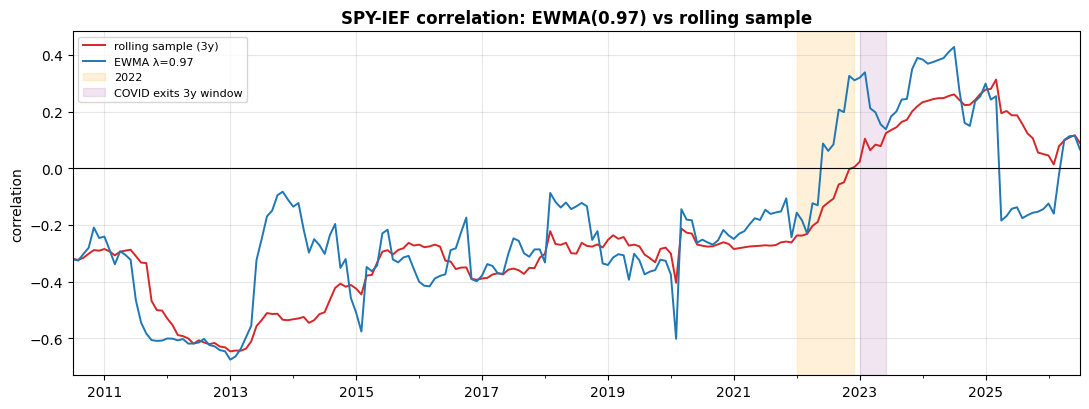

first time SPY-IEF corr > 0 :  sample=2022-12-31   EWMA=2022-06-30
comparability at 2010-07-31: sample=-0.3209  EWMA=-0.3209  (should match)


In [5]:
s_line = sample_corr("SPY", "IEF")
e_line = ewma_corr(snaps_by_lambda[BASE], "SPY", "IEF")

fig, ax = plt.subplots(figsize=(11, 4.2))
s_line.plot(ax=ax, label="rolling sample (3y)", color="#d62728", linewidth=1.4)
e_line.plot(ax=ax, label=f"EWMA λ={BASE}", color="#1f77b4", linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color="orange", alpha=0.15, label="2022")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-06-30"), color="purple", alpha=0.10, label="COVID exits 3y window")
ax.set_title("SPY-IEF correlation: EWMA(0.97) vs rolling sample", fontweight="bold")
ax.set_ylabel("correlation"); ax.set_xlabel(""); ax.legend(fontsize=8)
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

def first_cross_positive(s):
    pos = s[s > 0]
    return pos.index[0].date() if len(pos) else None
print(f"first time SPY-IEF corr > 0 :  sample={first_cross_positive(s_line)}   "
      f"EWMA={first_cross_positive(e_line)}")

# comparability check: EWMA(base) first snapshot must equal Step-3 sample at T1
t1 = s_line.index[0]
print(f"comparability at {t1.date()}: sample={s_line.iloc[0]:+.4f}  "
      f"EWMA={e_line.iloc[0]:+.4f}  (should match)")
assert abs(s_line.iloc[0] - e_line.iloc[0]) < 1e-9, "EWMA does not start from Step-3 sample"

### D2 — Average equity-block correlation: EWMA(0.97) vs rolling sample

Expected: both rise fast into the 2020 spike, but EWMA **decays smoothly**
afterward, whereas the rolling sample holds a ~3-year plateau then drops off a
cliff when the crisis window rolls off.

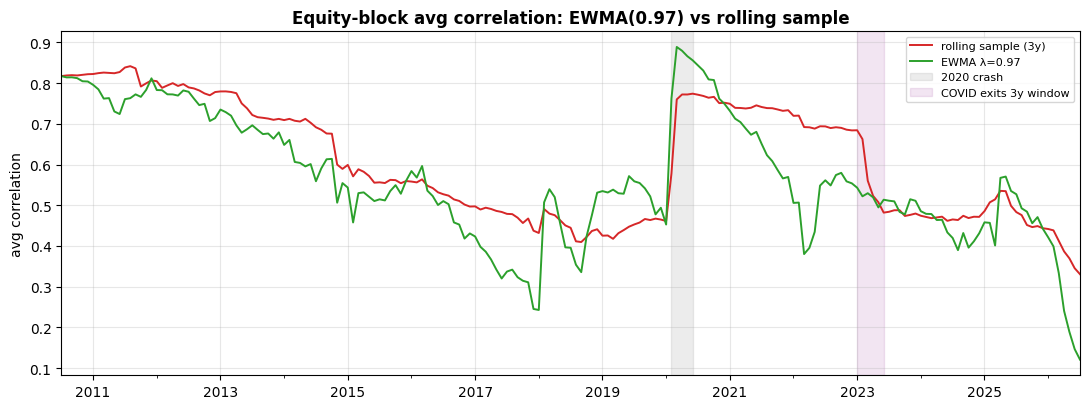

In [6]:
s_eq = sample_eq_avgcorr()
e_eq = ewma_eq_avgcorr(snaps_by_lambda[BASE])

fig, ax = plt.subplots(figsize=(11, 4.2))
s_eq.plot(ax=ax, label="rolling sample (3y)", color="#d62728", linewidth=1.4)
e_eq.plot(ax=ax, label=f"EWMA λ={BASE}", color="#2ca02c", linewidth=1.4)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"), color="grey", alpha=0.15, label="2020 crash")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-06-30"), color="purple", alpha=0.10, label="COVID exits 3y window")
ax.set_title("Equity-block avg correlation: EWMA(0.97) vs rolling sample", fontweight="bold")
ax.set_ylabel("avg correlation"); ax.set_xlabel(""); ax.legend(fontsize=8)
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### D3 — The three lambdas (SPY–IEF): memory/speed trade-off

Lower λ = shorter memory = **faster but noisier** (0.94 nervous); higher λ =
longer memory = **smoother but sluggish** (0.99 slow to react).

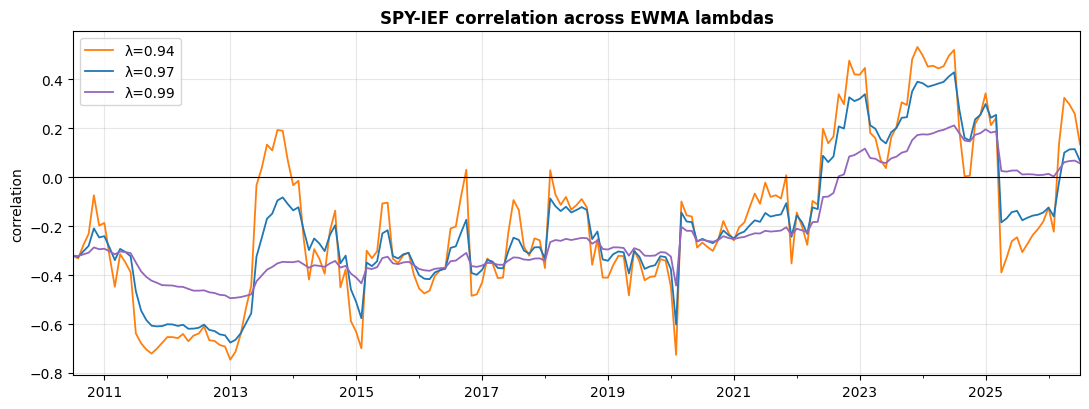

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.2))
colors = {0.94: "#ff7f0e", 0.97: "#1f77b4", 0.99: "#9467bd"}
for lam in LAMBDAS:
    ewma_corr(snaps_by_lambda[lam], "SPY", "IEF").plot(
        ax=ax, label=f"λ={lam}", color=colors[lam], linewidth=1.3)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("SPY-IEF correlation across EWMA lambdas", fontweight="bold")
ax.set_ylabel("correlation"); ax.set_xlabel(""); ax.legend()
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### D4 — Effective memory (half-life)

The half-life is how many weeks back a weight halves: `t½ = ln(0.5) / ln(λ)`.
It quantifies the trade-off in D3.

| λ | half-life (weeks) | character |
|-----|------|-----------|
| 0.94 | ≈ 11 | nervous / fast |
| 0.97 | ≈ 23 | base (RiskMetrics weekly) |
| 0.99 | ≈ 69 | sluggish / smooth |

In [8]:
for lam in LAMBDAS:
    hl = np.log(0.5) / np.log(lam)
    print(f"lambda={lam}: half-life = {hl:5.1f} weeks  (~{hl/52*12:.1f} months)")

lambda=0.94: half-life =  11.2 weeks  (~2.6 months)
lambda=0.97: half-life =  22.8 weeks  (~5.3 months)
lambda=0.99: half-life =  69.0 weeks  (~15.9 months)


## Conclusion & sanity notes

- **EWMA(0.97)** reacts to the 2022 stock–bond flip **earlier** than the rolling
  sample and has **no 2023 step artifact** (D1); the equity-block correlation
  **decays smoothly** after 2020 instead of a plateau-then-cliff (D2). This is
  exactly the step-3 weakness EWMA was meant to fix.
- **λ trade-off** is visible (D3) and quantified by half-life (D4): 0.94 fast/noisy,
  0.99 slow/smooth, 0.97 a sensible middle.
- **No shrinkage on top of EWMA** (pure comparison); a combined LW+EWMA is left as
  a possible Step-8-justified refinement.
- **Weekly returns only; no optimization.** Every snapshot asserted SPD.

Output written: `outputs/cov_ewma.parquet` (three lambdas, long format). Step 5
(optimization) can now compete sample vs LW vs EWMA as risk inputs.